CNN

1: Importación de Librerías y Configuración

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Rescaling, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Verificamos si hay disponibilidad de GPU para acelerar el entrenamiento
print("Versión de TensorFlow:", tf.__version__)
print("Dispositivos GPU disponibles:", tf.config.list_physical_devices('GPU'))

Versión de TensorFlow: 2.21.0
Dispositivos GPU disponibles: []


2: Carga de Datos (Train y Validation)

In [2]:
import os

# Definimos las rutas correctas relativas a la ubicación de tu notebook
TRAIN_DIR = './x-rays/train/'
VAL_DIR = './x-rays/validation/'

# Opcional: Verificación rápida para asegurarte de que Python encuentra las carpetas
if not os.path.exists(TRAIN_DIR):
    print(f"ERROR: No se encuentra la ruta de train en: {os.path.abspath(TRAIN_DIR)}")
else:
    print("¡Rutas verificadas con éxito!")

# Carga de datos de entrenamiento en escala de grises
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    color_mode='grayscale',
    image_size=(256, 256),
    batch_size=32,
    shuffle=True
)

# Carga de datos de validación
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    color_mode='grayscale',
    image_size=(256, 256),
    batch_size=32,
    shuffle=False
)

# Extraer el target (etiquetas reales) del set de validación para métricas posteriores
y_val = np.concatenate([y for _, y in val_ds], axis=0)

# Mapeo de Clases detectadas automáticamente por el directorio
class_names = train_ds.class_names
print("Clases detectadas (Target):", class_names)

¡Rutas verificadas con éxito!
Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Clases detectadas (Target): ['COVID-19', 'HEALTHY', 'PNEUMONIA']


3: Arquitectura de la Red Neuronal Convolucional (CNN)

In [3]:
# Definición de la forma de la entrada (Ancho, Alto, Canales)
# Al ser escala de grises, el último parámetro es 1.
input_shape = (256, 256, 1) 

model = Sequential([
    # Capa de entrada que define la estructura del tensor
    Input(shape=input_shape),
    
    # Capa de escalamiento: Normaliza los píxeles de [0, 255] a [0, 1] para mejorar la convergencia
    Rescaling(1./255),
    
    # Bloque Convolucional 1: Extrae características de bajo nivel (bordes, líneas)
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Bloque Convolucional 2: Combina las formas simples en texturas más complejas
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Bloque Convolucional 3: Patrones profundos específicos de la enfermedad
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Capa de aplanamiento: Transforma las matrices 2D a un vector 1D
    Flatten(),
    
    # Capa densamente conectada (Clasificador Neuronal)
    Dense(128, activation='relu'),
    Dropout(0.5), # Regularización para evitar memorización de imágenes
    
    # Capa de Salida: 3 neuronas correspondientes a las 3 clases objetivo
    # Usamos 'softmax' porque es una clasificación multiclase mutuamente excluyente
    Dense(len(class_names), activation='softmax')
])

# Compilación del modelo
model.compile(
    optimizer=Adam(learning_rate=1e-4), # Tasa de aprendizaje controlada
    loss='sparse_categorical_crossentropy', # Usado cuando las etiquetas son enteros (0, 1, 2)
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,870,403 (64.36 MB)

 Trainable params: 16,870,403 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

4: Entrenamiento del Modelo

In [4]:
epochs = 15 # Puedes incrementar este número según el comportamiento del Loss

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/15


c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 621ms/step - accuracy: 0.4501 - loss: 1.0493 - val_accuracy: 0.7667 - val_loss: 0.8994
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 635ms/step - accuracy: 0.6553 - loss: 0.8291 - val_accuracy: 0.6333 - val_loss: 0.7085
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 630ms/step - accuracy: 0.6952 - loss: 0.6896 - val_accuracy: 0.7000 - val_loss: 0.5898
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 639ms/step - accuracy: 0.7208 - loss: 0.6447 - val_accuracy: 0.8667 - val_loss: 0.5305
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 665ms/step - accuracy: 0.8348 - loss: 0.5329 - val_accuracy: 0.8111 - val_loss: 0.4687
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 633ms/step - accuracy: 0.8348 - loss: 0.4746 - val_accuracy: 0.7333 - val_loss: 0.4893
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 663ms/step - accuracy: 0.8262 - loss: 0.4390 - val_accuracy: 0.9222 - val_loss: 0.3603
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 610ms/step - accuracy: 0.8661 - loss: 0.3876 - val_accuracy: 0.9222 - val_

5: Visualización de Métricas de Entrenamiento

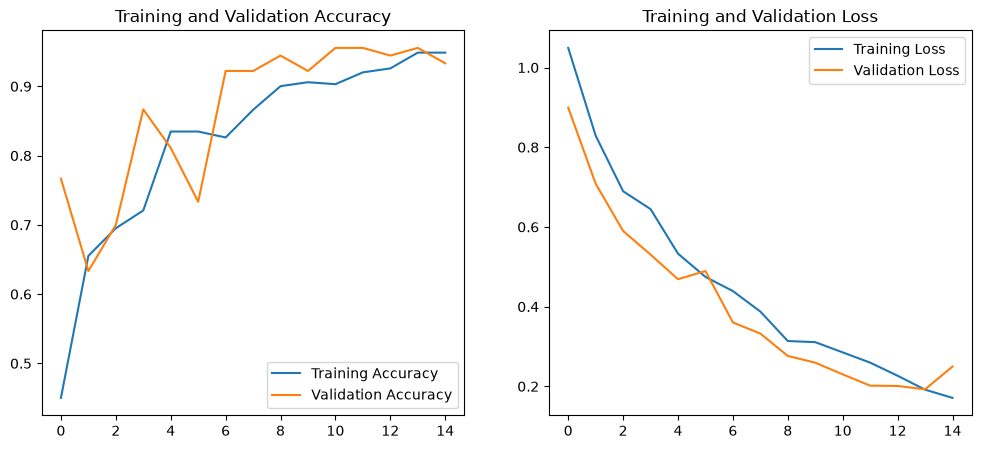

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


'''# Modificamos 'accuracy' por 'acc' para corregir el KeyError
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc)) # Dinámico según las épocas entrenadas

plt.figure(figsize=(12, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')'''

plt.show()

6: Predicciones y Reporte de Clasificación Profesional

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step
Reporte de Clasificación:

              precision    recall  f1-score   support

    COVID-19       0.96      0.90      0.93        30
     HEALTHY       1.00      0.93      0.97        30
   PNEUMONIA       0.85      0.97      0.91        30

    accuracy                           0.93        90
   macro avg       0.94      0.93      0.93        90
weighted avg       0.94      0.93      0.93        90



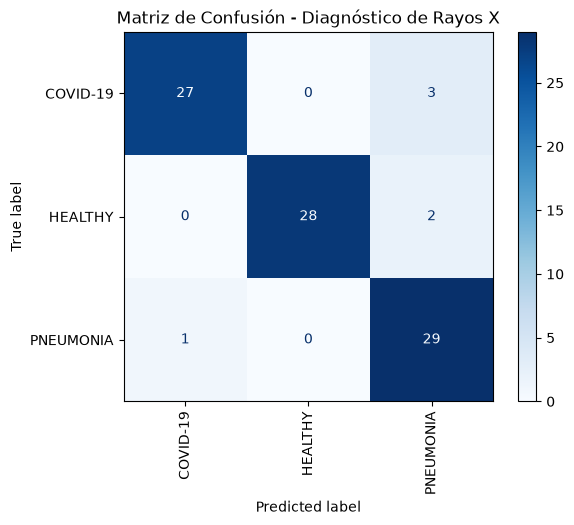

In [7]:
# Obtener las probabilidades de predicción del modelo
predictions = model.predict(val_ds)

# Convertir las probabilidades a índices de clase (el valor máximo)
y_pred = np.argmax(predictions, axis=1)

# Imprimir el reporte detallado de clasificación
print("Reporte de Clasificación:\n")
print(classification_report(y_val, y_pred, target_names=class_names))

# Mostrar la Matriz de Confusión
disp = ConfusionMatrixDisplay.from_predictions(
    y_val, 
    y_pred, 
    display_labels=class_names, 
    cmap=plt.cm.Blues,
    xticks_rotation='vertical'
)
plt.title("Matriz de Confusión - Diagnóstico de Rayos X")
plt.show()

7: Generación del Archivo de Entrega (Submission)

In [11]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf

# 1. Configuración de las rutas (ajustadas a tu estructura de carpetas)
LEADERBOARD_DIR = './x-rays/leaderboard/'
SUBMISSION_PATH = './x-rays/submission_levi.csv'

def crear_archivo_entrega(modelo, carpeta_leaderboard, ruta_salida):
    lista_imagenes = []
    predicciones_clase = []
    
    # Verificar si la carpeta existe antes de continuar
    if not os.path.exists(carpeta_leaderboard):
        raise FileNotFoundError(f"No se encontró la carpeta del leaderboard en: {os.path.abspath(carpeta_leaderboard)}")
    
    # 2. Listar los archivos .png y ordenarlos de forma natural/numérica (1.png, 2.png, ... 100.png)
    archivos = [f for f in os.listdir(carpeta_leaderboard) if f.endswith('.png')]
    archivos.sort(key=lambda var: [int(x) if x.isdigit() else x for x in re.split(r'(\d+)', var)])
    
    print(f"Detectadas {len(archivos)} imágenes en el leaderboard.")
    print("Procesando predicciones e integrando al archivo final...")
    
    # 3. Iterar sobre cada imagen, preprocesarla y predecir su categoría
    for archivo in archivos:
        ruta_img = os.path.join(carpeta_leaderboard, archivo)
        
        # Cargar la imagen en escala de grises y con el mismo tamaño con el que se entrenó el modelo (256x256)
        img = tf.keras.utils.load_img(ruta_img, color_mode='grayscale', target_size=(256, 256))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)  # Crear la dimensión del batch -> (1, 256, 256, 1)
        
        # Realizar la predicción con el modelo entrenado
        preds = modelo.predict(img_array, verbose=0)
        
        # Obtener el índice de la clase con mayor probabilidad (0, 1 o 2)
        clase_predicha = np.argmax(preds, axis=1)[0]
        
        # MODIFICACIÓN CLAVE: Extraemos solo el número entero eliminando la extensión '.png'
        id_numerico = int(archivo.split('.')[0])
        
        # Almacenar los resultados corregidos
        lista_imagenes.append(id_numerico)
        predicciones_clase.append(clase_predicha)
        
    # 4. Estructurar los datos en un DataFrame de Pandas y exportar a CSV
    df_submission = pd.DataFrame({
        'id': lista_imagenes,
        'prediction': predicciones_clase
    })
    
    df_submission.to_csv(ruta_salida, index=False)
    print(f"\n¡Éxito! Archivo de predicciones guardado correctamente en: {ruta_salida}")
    return df_submission


# EJECUCIÓN DE LA FUNCIÓN
# Asegúrate de usar el nombre de la variable de tu modelo entrenado (ej: 'model')
df_final = crear_archivo_entrega(model, LEADERBOARD_DIR, SUBMISSION_PATH)

# Mostrar una vista previa de las primeras 5 filas para verificar que el formato sea idéntico al de prueba
print("\nVista previa del archivo a presentar:")
print(df_final.head())

Detectadas 116 imágenes en el leaderboard.
Procesando predicciones e integrando al archivo final...

¡Éxito! Archivo de predicciones guardado correctamente en: ./x-rays/submission_levi.csv

Vista previa del archivo a presentar:
   id  prediction
0   1           0
1   2           1
2   3           2
3   4           0
4   5           0
